# Building a Perceptual Map with Multidimensional Scaling (MDS)

## Scenario
A meal kit product team wants to understand how similar or different its four plans
appear based on feature attributes. Derive a dissimilarity matrix, create a 2D
perceptual map, and interpret it for positioning decisions.

## Plans: QuickBite | Classic | Premium | FamilyFeast
## Data: `mealkit_plans.csv`


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('Exercise_Data')
if not DATA_DIR.exists():
    DATA_DIR = Path('/content/drive/Othercomputers/My PC/Desktop/All_Work_Related/Udacity/Applied_Statistics_ND/Exercises/Udacity Exercises Redone/')
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import euclidean_distances
from sklearn.manifold import MDS

df = pd.read_csv(DATA_DIR / 'mealkit_plans.csv')
print(df)

          plan  price_per_week  meals_per_week cuisine_variety  \
0    QuickBite              35               2        standard   
1      Classic              55               4        standard   
2      Premium              85               4         premium   
3  FamilyFeast              95               6        standard   

  dietary_options live_cooking_class  servings  
0              no                 no         2  
1             yes                 no         2  
2             yes                yes         2  
3             yes                 no         4  


## Step 1: Feature Engineering

In [4]:
# log-transform price to compress the wide price range
df['log_price']    = np.log(df['price_per_week'])
df['cuisine_flag'] = (df['cuisine_variety']    == 'premium').astype(int)
df['dietary_flag'] = (df['dietary_options']    == 'yes').astype(int)
df['class_flag']   = (df['live_cooking_class'] == 'yes').astype(int)

feat_cols = ['log_price','meals_per_week','servings','cuisine_flag','dietary_flag','class_flag']
X_raw = df[feat_cols].astype(float)
print("Feature matrix (before scaling):")
print(pd.DataFrame(X_raw.values, index=df['plan'], columns=feat_cols).round(3))

Feature matrix (before scaling):
             log_price  meals_per_week  servings  cuisine_flag  dietary_flag  \
plan                                                                           
QuickBite          NaN             NaN       NaN           NaN           NaN   
Classic            NaN             NaN       NaN           NaN           NaN   
Premium            NaN             NaN       NaN           NaN           NaN   
FamilyFeast        NaN             NaN       NaN           NaN           NaN   

             class_flag  
plan                     
QuickBite           NaN  
Classic             NaN  
Premium             NaN  
FamilyFeast         NaN  


## Step 2: Standardize and Compute Dissimilarity Matrix

In [5]:
X = StandardScaler().fit_transform(X_raw)
D = euclidean_distances(X)
df_D = pd.DataFrame(D, index=df['plan'], columns=df['plan'])
print("Dissimilarity matrix:")
print(df_D.round(3))

Dissimilarity matrix:
plan         QuickBite  Classic  Premium  FamilyFeast
plan                                                 
QuickBite        0.000    2.940    4.802        5.008
Classic          2.940    0.000    3.447        3.042
Premium          4.802    3.447    0.000        4.252
FamilyFeast      5.008    3.042    4.252        0.000


## Step 3: Fit MDS and Plot Perceptual Map

MDS Stress: 0.3200


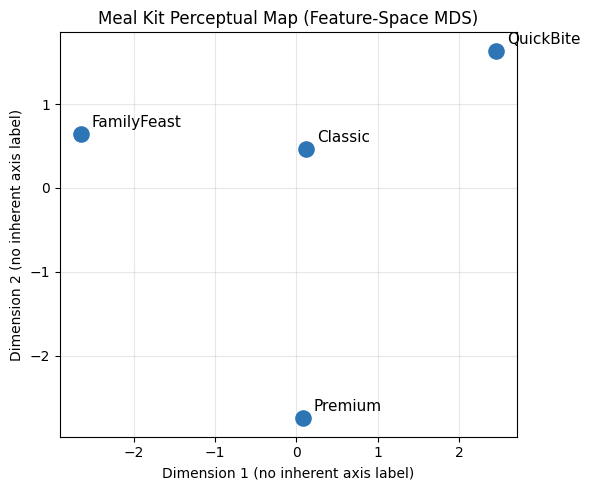

In [6]:
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(D)
df_mds = pd.DataFrame({'plan': df['plan'], 'x': coords[:,0], 'y': coords[:,1]})
# sklearn stress_ is the raw (unnormalized) sum of squared residuals.
# Kruskal's Stress-1 = sqrt(stress_ / sum(D^2)) is the interpretable metric.
kruskal_s1 = np.sqrt(mds.stress_ / (np.sum(D**2) + 1e-10))
print(f"MDS Raw Stress (sklearn): {mds.stress_:.4f}")
print(f"Kruskal's Stress-1 (interpretable): {kruskal_s1:.4f}")
print("  Guideline: <0.05 excellent, <0.10 good, <0.20 fair, >0.20 poor")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_mds['x'], df_mds['y'], s=120, color='#2E75B6', zorder=3)
for _, row in df_mds.iterrows():
    ax.annotate(row['plan'], (row['x'], row['y']),
                textcoords='offset points', xytext=(8, 5), fontsize=11)
ax.set_xlabel('Dimension 1 (no inherent axis label)')
ax.set_ylabel('Dimension 2 (no inherent axis label)')
ax.set_title('Meal Kit Perceptual Map (Feature-Space MDS)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 4: Identify Closest Substitute and Whitespace

In [7]:
# Closest substitute: minimum off-diagonal value in D
np.fill_diagonal(D, np.inf)
idx = np.unravel_index(D.argmin(), D.shape)
plan_a = df['plan'].iloc[idx[0]]
plan_b = df['plan'].iloc[idx[1]]
dist   = D[idx]
print(f"Closest substitutes: {plan_a} vs {plan_b}  (distance = {dist:.3f})")
np.fill_diagonal(D, 0)

# Whitespace: largest average distance to all others
avg_dist = df_D.replace(0, np.nan).mean(axis=1)
print(f"\nAverage distances from each plan:")
print(avg_dist.round(3))
print(f"\nWhitespace bundle: {avg_dist.idxmax()}  (avg distance = {avg_dist.max():.3f})")

Closest substitutes: QuickBite vs Classic  (distance = 2.940)

Average distances from each plan:
plan
QuickBite      4.250
Classic        3.143
Premium        4.167
FamilyFeast    4.100
dtype: float64

Whitespace bundle: QuickBite  (avg distance = 4.250)


## Positioning Interpretation

**Closest substitutes: QuickBite and Classic (distance = 2.940)**
These two plans share a standard cuisine tier and the same number of servings.
The main distinction is dietary options (Classic includes them, QuickBite does not)
and price ($55 vs $35). Their proximity suggests they compete for budget-conscious
customers — launching Classic without differentiating messaging risks cannibalizing
QuickBite's base.

**Whitespace: QuickBite (avg distance = 4.250)**
Despite being closest to Classic, QuickBite sits at the greatest average distance
from the full portfolio because it is very far from both Premium (4.80) and
FamilyFeast (5.01). It occupies the most distinct position in the portfolio —
the entry-level tier with minimal features and the lowest price. If demand exists
for this value-focused positioning, QuickBite has the clearest differentiation story.

**Note:** This map reflects feature-space proximity, not direct customer perception.
Validate with customer preference data or perceptual survey ratings where available.
